# Array Processing Project 1

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from utils import *

# Estimating Angles and Frequencies

### First generate data and analyze it

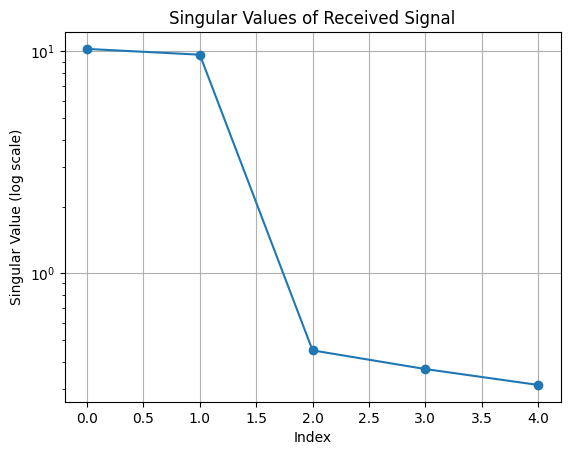

In [2]:
# Parameters
M = 5
N = 20
delta = 0.5
theta = [-20, 30]
f = [0.1, 0.3]
SNR = 20

# Generate data
X, A, S = gendata(M, N, delta, theta, f, SNR)

# Plot singular values of the received signal
U, Sigma, Vh = np.linalg.svd(X)
plt.figure()
plt.semilogy(Sigma, 'o-')
plt.title('Singular Values of Received Signal')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.grid()
plt.show()

### Estimation of directions and frequencies using ESPIRT

In [3]:
# ESPRIT Algorithm for DOA Estimation
angles = esprit(X, d=2)
print(f"Estimated DOA (degrees): {angles} at SNR = {SNR} dB")

# ESPRIT Algorithm for Frequency Estimation
frequencies = espritfreq(X, d=2)
print(f"Estimated Frequencies: {frequencies} at SNR = {SNR} dB")

# Joint DOA and Frequency Estimation
angles_joint, frequencies_joint = joint(X, d=2, m=M)
print(f"Joint Estimated DOA (degrees): {angles_joint} at SNR = {SNR} dB")
print(f"Joint Estimated Frequencies: {frequencies_joint} at SNR = {SNR} dB")

Estimated DOA (degrees): [-19.91012403  30.27545743] at SNR = 20 dB
Estimated Frequencies: [0.09972043 0.30121284] at SNR = 20 dB
Joint Estimated DOA (degrees): [-19.86433545  30.21526975] at SNR = 20 dB
Joint Estimated Frequencies: [0.09954368 0.30028172] at SNR = 20 dB


### Comparison of the estimation algorithms

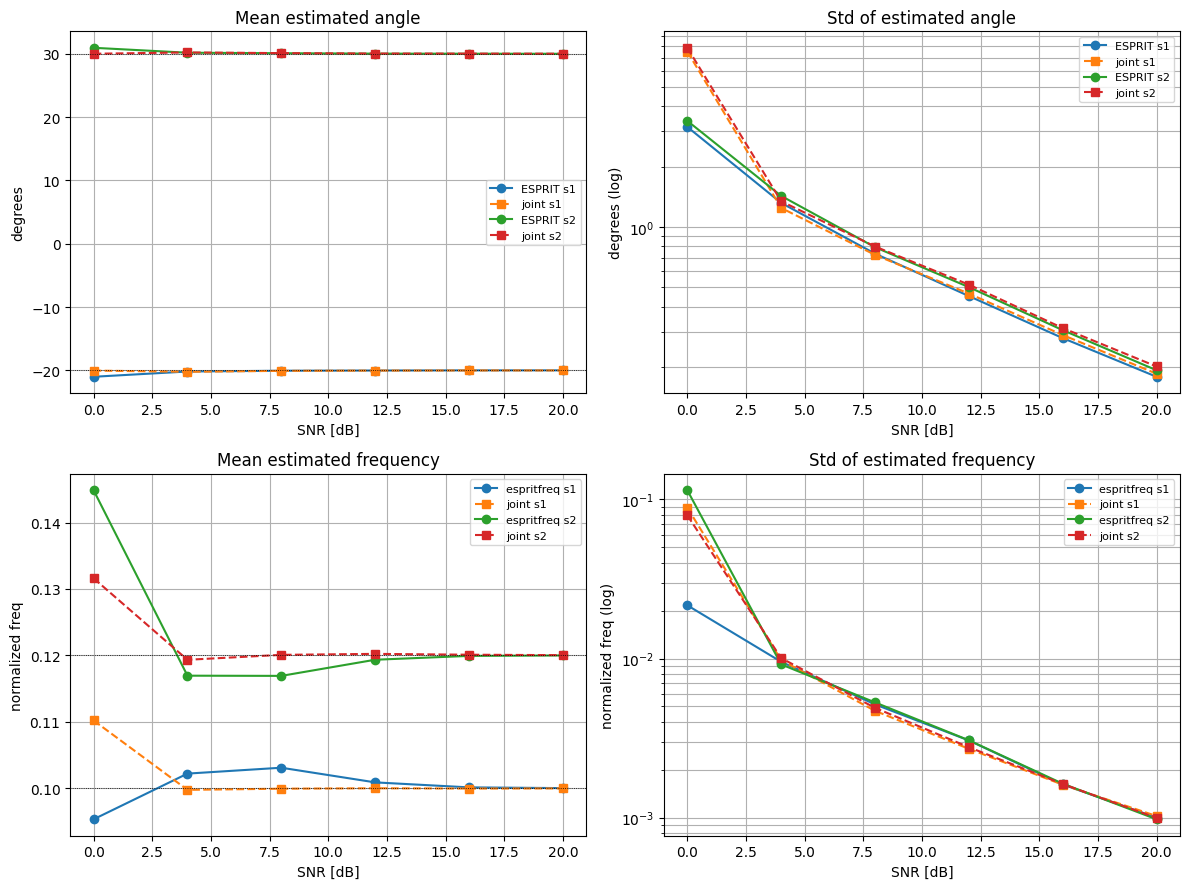

In [4]:
# Experiment parameters 
M_exp = 3
d = 2
f_exp = np.array([0.10, 0.12])
m_smooth = 2  # smoothing factor for joint()
SNR_dB = np.arange(0, 21, 4)  # 0, 4, ..., 20
n_runs = 1000

# angles
th_esprit = np.zeros((len(SNR_dB), n_runs, d))
th_joint  = np.zeros((len(SNR_dB), n_runs, d))

# frequencies
f_espfreq = np.zeros((len(SNR_dB), n_runs, d))
f_joint   = np.zeros((len(SNR_dB), n_runs, d))

# Monte Carlo 
rng = np.random.default_rng(0)             
for i, snr in enumerate(SNR_dB):
    for r in range(n_runs):
        X, A, S = gendata(M, N, delta, theta, f_exp, snr)

        # ESPRIT angles
        th = esprit(X, d)
        th_esprit[i, r] = match(np.real(th), theta)

        # ESPRIT-freq 
        ff = espritfreq(X, d)
        f_espfreq[i, r] = match(np.real(ff), f_exp)

        # Joint 
        thj, fj = joint(X, d, m_smooth)
        thj, fj = match_joint(np.real(thj), np.real(fj), theta, f_exp)
        th_joint[i, r] = thj
        f_joint[i, r]  = fj


# Statistics over runs 
th_e_mean, th_e_std = th_esprit.mean(axis=1), th_esprit.std(axis=1) 
th_j_mean, th_j_std = th_joint.mean(axis=1), th_joint.std(axis=1)
f_f_mean,  f_f_std  = f_espfreq.mean(axis=1), f_espfreq.std(axis=1)
f_j_mean,  f_j_std  = f_joint.mean(axis=1), f_joint.std(axis=1)


# Plot: 2x2 (angle mean / angle std / freq mean / freq std) 
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# Angle means
for k in range(d):
    ax[0,0].plot(SNR_dB, th_e_mean[:,k], 'o-',  label=f'ESPRIT s{k+1}')
    ax[0,0].plot(SNR_dB, th_j_mean[:,k], 's--', label=f'joint s{k+1}')
for t in theta:
    ax[0,0].axhline(t, color='k', lw=0.6, ls=':')
ax[0,0].set_title('Mean estimated angle'); ax[0,0].set_ylabel('degrees')
ax[0,0].set_xlabel('SNR [dB]'); ax[0,0].legend(fontsize=8); ax[0,0].grid(True)

# Angle std
for k in range(d):
    ax[0,1].semilogy(SNR_dB, th_e_std[:,k], 'o-',  label=f'ESPRIT s{k+1}')
    ax[0,1].semilogy(SNR_dB, th_j_std[:,k], 's--', label=f'joint s{k+1}')
ax[0,1].set_title('Std of estimated angle'); ax[0,1].set_ylabel('degrees (log)')
ax[0,1].set_xlabel('SNR [dB]'); ax[0,1].legend(fontsize=8); ax[0,1].grid(True, which='both')

# Frequency means
for k in range(d):
    ax[1,0].plot(SNR_dB, f_f_mean[:,k], 'o-',  label=f'espritfreq s{k+1}')
    ax[1,0].plot(SNR_dB, f_j_mean[:,k], 's--', label=f'joint s{k+1}')
for fv in f_exp:
    ax[1,0].axhline(fv, color='k', lw=0.6, ls=':')
ax[1,0].set_title('Mean estimated frequency'); ax[1,0].set_ylabel('normalized freq')
ax[1,0].set_xlabel('SNR [dB]'); ax[1,0].legend(fontsize=8); ax[1,0].grid(True)

# Frequency std
for k in range(d):
    ax[1,1].semilogy(SNR_dB, f_f_std[:,k], 'o-',  label=f'espritfreq s{k+1}')
    ax[1,1].semilogy(SNR_dB, f_j_std[:,k], 's--', label=f'joint s{k+1}')
ax[1,1].set_title('Std of estimated frequency'); ax[1,1].set_ylabel('normalized freq (log)')
ax[1,1].set_xlabel('SNR [dB]'); ax[1,1].legend(fontsize=8); ax[1,1].grid(True, which='both')

plt.tight_layout()
plt.show()

### Creating two zero-forcing beamformers 

In [5]:
# Create near noiseless data
X, _, _ = gendata(M, N, delta, theta, f, SNR=100)  

# Beamformer 1: Using angle information
theta_hat = esprit(X, d)
A_hat = np.column_stack([a(th, M, delta).flatten() for th in theta_hat])  # M x d
W_theta = np.linalg.pinv(A_hat)  # this is W^H directly (d x M)
S_theta = W_theta @ X # recovered sources, d x N

# Beamformer 2: Using frequency information
f_hat = espritfreq(X, d)
S_hat = np.array([np.exp(1j*2*np.pi*fi*np.arange(N)) for fi in f_hat])  # d x N
W_f = S_hat @ np.linalg.pinv(X)  # d x M, this is W^H
S_freq = W_f @ X               


# Align the rows
S_theta_aligned = match_rows(S, S_theta)
S_freq_aligned  = match_rows(S, S_freq)

# Calculate MSE
mse_theta = np.mean(np.abs(S - S_theta_aligned)**2)
mse_freq  = np.mean(np.abs(S - S_freq_aligned)**2)

print(f"MSE angle-based (esprit): {mse_theta:.3e}")
print(f"MSE frequency-based (espritfreq): {mse_freq:.3e}")

MSE angle-based (esprit): 2.132e-01
MSE frequency-based (espritfreq): 7.132e-01


### Comparing the spatial responses of the beamformers

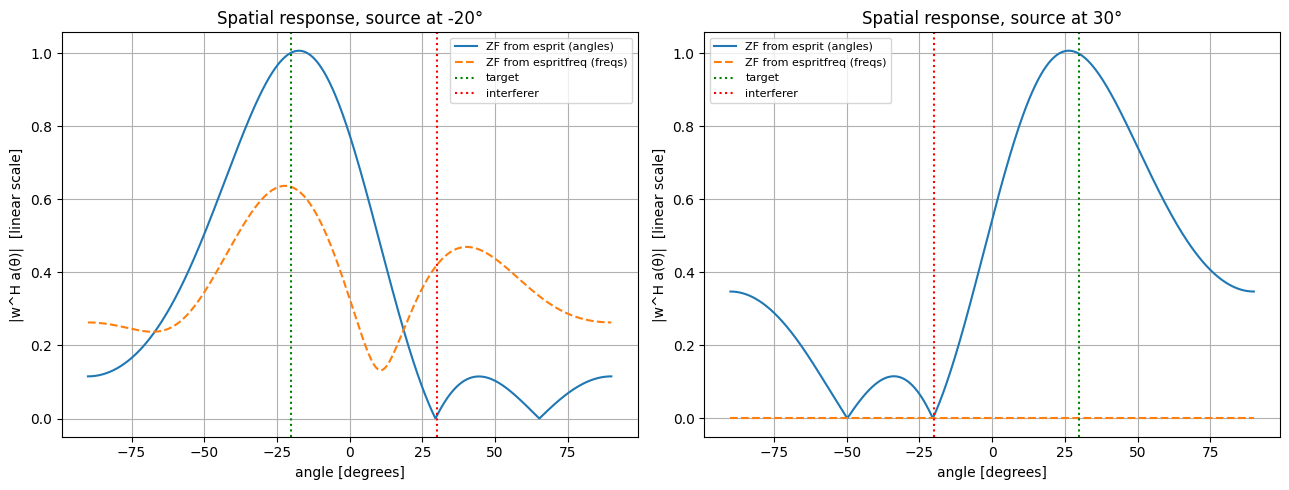

In [6]:
# Parameters
M = 3
N = 20
d = 2
delta = 0.5
theta_true = [-20, 30]
f_true = [0.1, 0.12]
SNR = 10

# Generate noisy data 
X, A, S = gendata(M, N, delta, theta_true, f_true, SNR)


# Rebuild BOTH beamformers here with M = 3
theta_hat = esprit(X, d)
A_hat = np.column_stack([a(th, M, delta).flatten() for th in theta_hat])
W_theta = np.linalg.pinv(A_hat)                     

f_hat = espritfreq(X, d)
S_hat = np.array([np.exp(1j*2*np.pi*fi*np.arange(N)) for fi in f_hat])
W_f = S_hat @ np.linalg.pinv(X)  


# Reorder W_f rows so row i targets the same source as W_theta row i
order_theta = [target_index(W_theta[i], theta_true, M, delta) for i in range(d)]
order_f = [target_index(W_f[i], theta_true, M, delta) for i in range(d)]


# build a map so both index by true-source order
W_theta_sorted = np.zeros_like(W_theta)
W_f_sorted = np.zeros_like(W_f)
for i in range(d):
    W_theta_sorted[order_theta[i]] = W_theta[i]
    W_f_sorted[order_f[i]] = W_f[i]


# Compute spatial responses y(theta) = |w^H a(theta)| 
angles = np.linspace(-90, 90, 1000)

# Plot one subplot per source 
fig, axes = plt.subplots(1, d, figsize=(13, 5))
for i in range(d):
    y_theta = spatial_response(W_theta_sorted[i], M, delta, angles)
    y_freq  = spatial_response(W_f_sorted[i], M, delta, angles)

    # y_theta_dB = 10*np.log10(y_theta + 1e-12)
    # y_freq_dB = 10*np.log10(y_freq + 1e-12)

    ax = axes[i]
    ax.plot(angles, y_theta, label='ZF from esprit (angles)')
    ax.plot(angles, y_freq,  label='ZF from espritfreq (freqs)', linestyle='--')
    ax.axvline(theta_true[i],  color='g', linestyle=':', label='target')
    ax.axvline(theta_true[1-i], color='r', linestyle=':', label='interferer')
    ax.set_title(f'Spatial response, source at {theta_true[i]}°')
    ax.set_xlabel('angle [degrees]')
    ax.set_ylabel('|w^H a(θ)|  [linear scale]')
    # ax.set_ylim(-60, 5)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Channel Equalization

In [7]:
# Set parameters
N = 500
P = 4
sigma = 0.0
h = np.array([1, -1, 1, -1]) 

# Create the data
s = random_qpsk(N)
x = gendata_conv(h, s, P, N, sigma)
print("channel taps:", h)   
print("x shape:", x.shape) 

channel taps: [ 1 -1  1 -1]
x shape: (2000,)


In [8]:
# Build the 2P x (N-1) data matrix 
rows = 2 * P                      
cols = N - 1          

X = np.zeros((rows, cols), dtype=complex)
for n in range(cols):
    start = n * P                  
    X[:, n] = x[start : start + rows]   

# Check rank
sv = np.linalg.svd(X, compute_uv=False)
tol = 1e-9
rank = np.sum(sv > tol)
print(f"P={P}: X is {X.shape}, rank = {np.sum(sv > tol)}")        

P=4: X is (8, 499), rank = 2


In [9]:
# Now oversample with a factor of 8 
P = 8
x = gendata_conv(h, s, P, N, 0.0)
rows = 2 * P

X = np.zeros((rows, N - 1), dtype=complex)
for n in range(cols):
    X[:, n] = x[n * P : n * P + rows]

# Look at rank
sv = np.linalg.svd(X, compute_uv=False)
print(f"P={P}: X is {X.shape}, rank = {np.sum(sv > tol)}")

P=8: X is (16, 499), rank = 2


### Zero-forcing and Wiener equalizer

In [10]:
# Set parameters
N = 500
P = 4
sigma = 0.5

# Create data
s = random_qpsk(N)
x = gendata_conv(h, s, P, N, sigma)

# Stacked data matrix 
rows = 2 * P
X = np.zeros((rows, N - 1), dtype=complex)
for n in range(N - 1):
    X[:, n] = x[n * P : n * P + rows]

# Build the stacked convolution matrix
H = build_H(h, P)

# Compare ZF noise gain ||w||^2 for each delay and use the best one
for d in range(H.shape[1]):
    w = zf_equalizer(H, d)
    print(f"delay d={d}: ZF noise gain ||w||^2 = {np.linalg.norm(w)**2:.3f}")

delay d=0: ZF noise gain ||w||^2 = 0.250
delay d=1: ZF noise gain ||w||^2 = 0.250


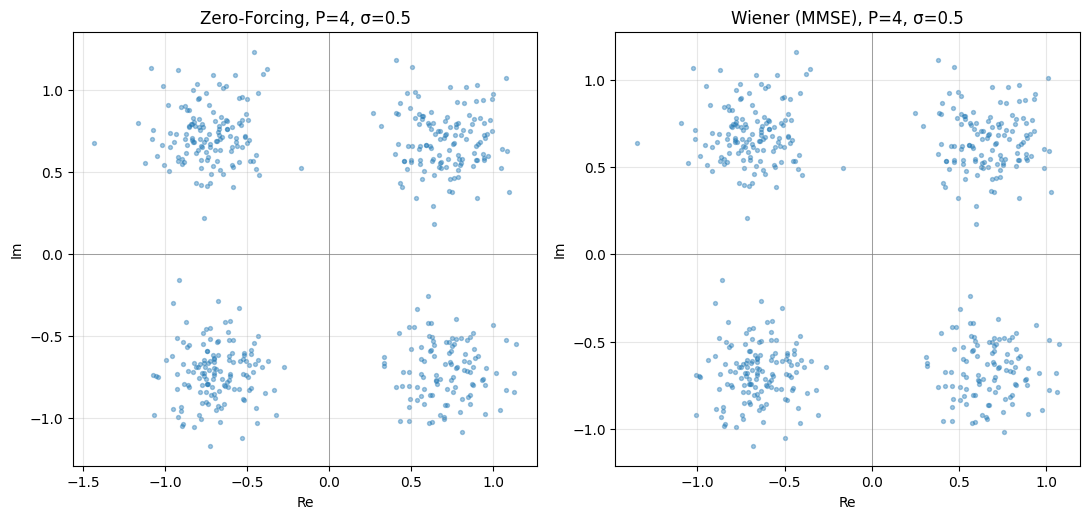

In [11]:
# Choose delay and look at recovered signals
d = 1   

# Build beamformers for chosen delay
w_zf = zf_equalizer(H, d)
w_wiener = wiener_equalizer(H, d, sigma)

# Recovered signals
s_zf = w_zf.conj() @ X          
s_wiener = w_wiener.conj() @ X 

# Plot in the complex plane
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, est, name in [(axes[0], s_zf, 'Zero-Forcing'),
                      (axes[1], s_wiener, 'Wiener (MMSE)')]:
    ax.scatter(est.real, est.imag, s=8, alpha=0.4)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'{name}, P={P}, σ={sigma}')
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Now double the upsampling rate

P=4: ZF noise gain ||w||^2 = 0.2500, channel ||h||^2 = 4.0
P=8: ZF noise gain ||w||^2 = 0.1250, channel ||h||^2 = 8.0


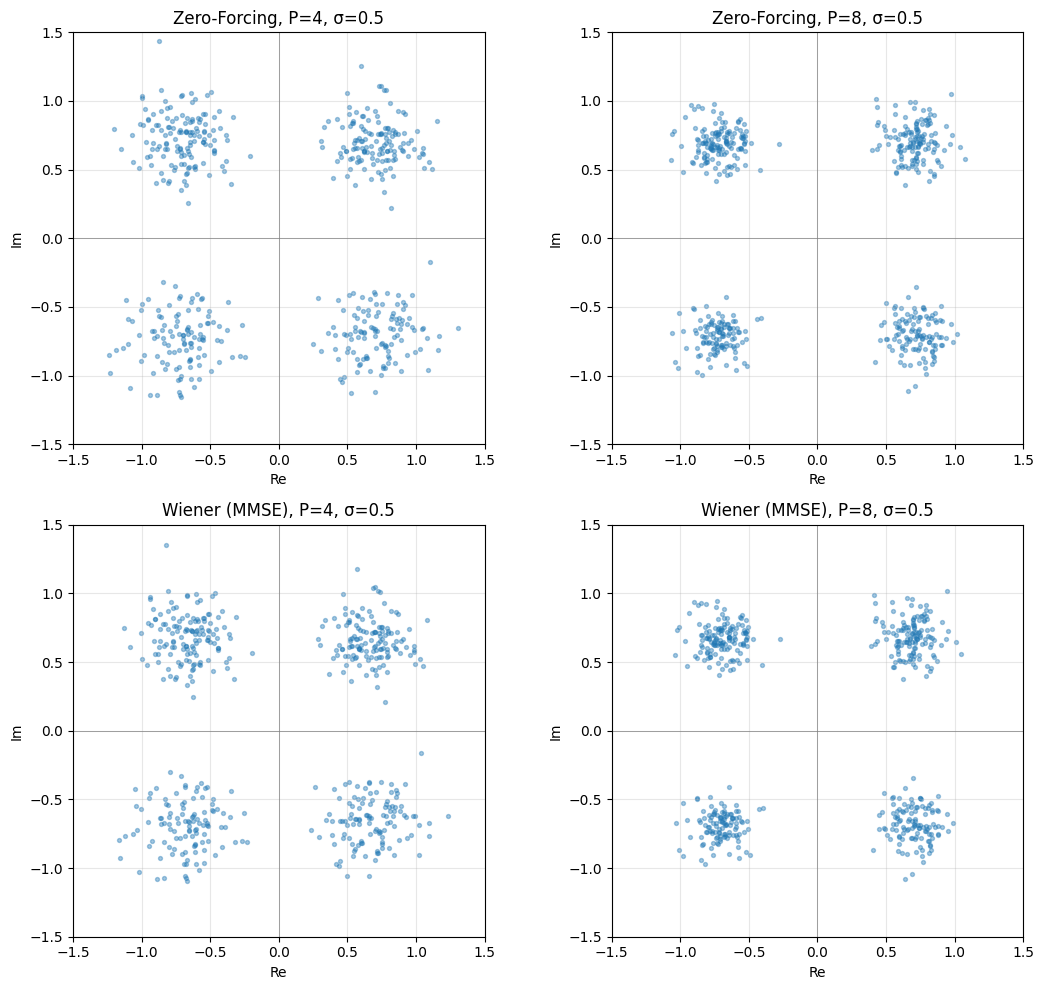

In [13]:
# Set parameters
N = 500
sigma = 0.5

# Use same symbol stream for a fair comparison
s = random_qpsk(N)                       

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for col, P in enumerate((4, 8)):
    # Create appropriate channel response
    if P == 8:
        h = [1, 1, -1, -1, 1, 1, -1, -1]

    # Generate oversampled data at this P
    x = gendata_conv(h, s, P, N, sigma)

    # Stacked data matrix
    rows = 2 * P
    X = np.zeros((rows, N - 1), dtype=complex)
    for n in range(N - 1):
        X[:, n] = x[n * P : n * P + rows]

    # Create stacked convolution matrix
    H = build_H(h, P)

    # Choose delay
    d = 1                               

    w_zf = zf_equalizer(H, d)
    w_wiener = wiener_equalizer(H, d, sigma)

    s_zf = w_zf.conj() @ X
    s_wiener = w_wiener.conj() @ X

    print(f"P={P}: ZF noise gain ||w||^2 = {np.linalg.norm(w_zf)**2:.4f}, "
          f"channel ||h||^2 = {np.linalg.norm(h)**2:.1f}")

    for row, est, name in [(0, s_zf, 'Zero-Forcing'),
                           (1, s_wiener, 'Wiener (MMSE)')]:
        ax = axes[row, col]
        ax.scatter(est.real, est.imag, s=8, alpha=0.4)
        ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
        ax.set_title(f'{name}, P={P}, σ={sigma}')
        ax.set_xlabel('Re'); ax.set_ylabel('Im')
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)  

plt.tight_layout()
plt.show()